<a href="https://colab.research.google.com/github/FusRaDa/biot670i_capstone_vaccination_project/blob/kalkidan-analysis-engine/perin_notebooks/Population_Normalized_Incidence_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Population-Normalized Incidence Analysis

## BIOT 670I Vaccination Project – Analysis Engine

This notebook extends the preliminary analysis of vaccination coverage and
reported measles cases by using population-normalized disease incidence
(cases per 100,000 population).

The analysis will evaluate:

1. Baseline association between measles vaccination coverage and measles incidence per 100,000.
2. Time-lagged associations from 0–5 years.
3. Changes in correlation strength across lag periods.
4. Statistical uncertainty and limitations associated with missing data
   and decreasing sample size at longer lag periods.

These analyses examine ecological associations and should not be interpreted
as evidence of causation.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

print("Analysis environment ready.")

Analysis environment ready.



## Load Population and Disease Case Data

Disease case and state population data prepared by the disease-incidence
pipeline are used to calculate population-normalized incidence rates for
the statistical analysis.



In [ ]:
base_url = "https://raw.githubusercontent.com/FusRaDa/biot670i_capstone_vaccination_project/main/app/data/"

cases = pd.read_csv(base_url + "tycho_cases.csv")
population = pd.read_csv(base_url + "population.csv")

print("Cases data:")
display(cases.head())

print("\nPopulation data:")
display(population.head())

print("\nCases columns:")
print(cases.columns.tolist())

print("\nPopulation columns:")
print(population.columns.tolist())

Cases data:


,year,state,measles_cases,mumps_cases,pertussis_cases
0,1995,AK,NaN,13.0,1.0
1,1995,AL,NaN,4.0,38.0
2,1995,AR,2.0,10.0,41.0
3,1995,AZ,10.0,2.0,151.0
4,1995,CA,108.0,206.0,463.0



Population data:


,state,year,population
0,AL,1995,4296800.0
1,AL,1996,4331102.0
2,AL,1997,4367935.0
3,AL,1998,4404701.0
4,AL,1999,4430141.0



Cases columns:
['year', 'state', 'measles_cases', 'mumps_cases', 'pertussis_cases']

Population columns:
['state', 'year', 'population']


## Population-Normalized Disease Incidence

Disease case counts are merged with state population estimates by state and
year. Incidence is expressed as reported cases per 100,000 population to
improve comparability across states with different population sizes.

In [ ]:
panel_df = pd.merge(
    cases,
    population,
    on=["state", "year"],
    how="inner"
)

panel_df["measles_cases_per_100k"] = (
    panel_df["measles_cases"] / panel_df["population"]
) * 100_000

print("Merged dataset shape:", panel_df.shape)

display(
    panel_df[
        ["year", "state", "measles_cases",
         "population", "measles_cases_per_100k"]
    ].head(10)
)

Merged dataset shape: (1128, 7)


,year,state,measles_cases,population,measles_cases_per_100k
0,1995,AK,NaN,604412.0,NaN
1,1995,AL,NaN,4296800.0,NaN
2,1995,AR,2.0,2535399.0,0.078883
3,1995,AZ,10.0,4432499.0,0.225606
4,1995,CA,108.0,31696582.0,0.340731
5,1995,CO,24.0,3826653.0,0.627180
6,1995,CT,2.0,3324144.0,0.060166
7,1995,DE,NaN,729734.0,NaN
8,1995,FL,9.0,14537875.0,0.061907
9,1995,GA,2.0,7328413.0,0.027291


## Vaccination Coverage Data

Vaccination coverage data are merged with the population-normalized disease
incidence data by state and year to create the analysis-ready dataset.

In [ ]:
coverage = pd.read_csv(base_url + "nis_vacc_coverage.csv")

print("Vaccination coverage data:")
display(coverage.head())

print("\nCoverage columns:")
print(coverage.columns.tolist())

print("\nDataset shape:")
print(coverage.shape)

Vaccination coverage data:


,state,year,measles_coverage_pct,measles_n,measles_n_vaccinated,mumps_coverage_pct,mumps_n,mumps_n_vaccinated,pertussis_coverage_pct,pertussis_n,pertussis_n_vaccinated
0,AK,1995,89.86,194.0,177.0,89.86,194.0,177.0,77.58,194.0,159.0
1,AK,1996,84.55,260.0,225.0,84.55,260.0,225.0,78.25,260.0,210.0
2,AK,1997,87.41,291.0,257.0,87.41,291.0,257.0,80.98,291.0,242.0
3,AK,1998,87.06,34.0,30.0,87.06,34.0,30.0,82.01,34.0,28.0
4,AK,1999,90.67,349.0,321.0,90.67,349.0,321.0,83.54,349.0,296.0



Coverage columns:
['state', 'year', 'measles_coverage_pct', 'measles_n', 'measles_n_vaccinated', 'mumps_coverage_pct', 'mumps_n', 'mumps_n_vaccinated', 'pertussis_coverage_pct', 'pertussis_n', 'pertussis_n_vaccinated']

Dataset shape:
(1545, 11)


## Analysis-Ready Measles Dataset

Vaccination coverage is linked with population-normalized measles incidence
by state and calendar year. Rows without both vaccination coverage and
measles incidence are excluded from the correlation analysis.

In [ ]:
measles_df = coverage[
    ["state", "year", "measles_coverage_pct"]
].merge(
    panel_df[
        ["state", "year", "measles_cases_per_100k"]
    ],
    on=["state", "year"],
    how="inner"
)

# Remove rows missing either variable
measles_df = measles_df.dropna(
    subset=["measles_coverage_pct", "measles_cases_per_100k"]
)

print("Analysis-ready dataset shape:", measles_df.shape)

display(measles_df.head(10))

Analysis-ready dataset shape: (314, 4)


,state,year,measles_coverage_pct,measles_cases_per_100k
1,AK,1996,84.55,10.352154
2,AK,1997,87.41,7.830751
3,AK,1998,87.06,4.677932
4,AK,1999,90.67,4.641641
5,AK,2000,88.81,0.159245
21,AK,2016,85.83,0.000000
22,AK,2017,89.56,0.000000
26,AL,1998,90.55,0.022703
27,AL,1999,90.05,0.022573
30,AL,2002,91.59,0.267852


In [ ]:
print(
    "Duplicate state-year rows:",
    measles_df.duplicated(["state", "year"]).sum()
)

print(
    "Year range:",
    measles_df["year"].min(),
    "-",
    measles_df["year"].max()
)

print(
    "Number of states:",
    measles_df["state"].nunique()
)

Duplicate state-year rows: 0
Year range: 1995 - 2017
Number of states: 49


## Baseline Correlation Using Population-Normalized Incidence

Pearson and Spearman correlations are used to examine the same-year
association between measles vaccination coverage and reported measles
incidence per 100,000 population.

This is an ecological association and does not establish causation.

In [ ]:
baseline_r, baseline_p = pearsonr(
    measles_df["measles_coverage_pct"],
    measles_df["measles_cases_per_100k"]
)

baseline_rho, baseline_spearman_p = spearmanr(
    measles_df["measles_coverage_pct"],
    measles_df["measles_cases_per_100k"]
)

print("NORMALIZED MEASLES BASELINE ANALYSIS")
print("------------------------------------")
print(f"Pearson r:      {baseline_r:.3f}")
print(f"Pearson p:      {baseline_p:.4f}")
print(f"Spearman rho:   {baseline_rho:.3f}")
print(f"Spearman p:     {baseline_spearman_p:.4f}")
print(f"n:              {len(measles_df)}")

NORMALIZED MEASLES BASELINE ANALYSIS
------------------------------------
Pearson r:      -0.181
Pearson p:      0.0013
Spearman rho:   -0.175
Spearman p:     0.0018
n:              314




Using population-normalized measles incidence, the baseline analysis showed
a weak negative association between vaccination coverage and measles incidence
(Pearson r = -0.181, p = 0.0013, n = 314).

The Spearman correlation produced a similar result (rho = -0.175,
p = 0.0018), suggesting that the observed negative association is not limited
to the Pearson linear correlation measure.

Compared with the preliminary analysis using raw measles case counts
(r = -0.155), population normalization produced a slightly stronger negative
association. However, the magnitude of the relationship remains weak.

These results represent ecological associations across state-year
observations and should not be interpreted as evidence of causation.

In [8]:
lag_results = []

for lag in range(0, 6):

    coverage_lag = measles_df[
        ["state", "year", "measles_coverage_pct"]
    ].copy()

    incidence = measles_df[
        ["state", "year", "measles_cases_per_100k"]
    ].copy()

    # Match coverage in year t with incidence in year t + lag
    incidence["year"] = incidence["year"] - lag

    temp = coverage_lag.merge(
        incidence,
        on=["state", "year"],
        how="inner"
    ).dropna()

    r, p = pearsonr(
        temp["measles_coverage_pct"],
        temp["measles_cases_per_100k"]
    )

    lag_results.append({
        "lag_years": lag,
        "pearson_r": r,
        "p_value": p,
        "n": len(temp)
    })

normalized_lag_results = pd.DataFrame(lag_results)

display(normalized_lag_results)

,lag_years,pearson_r,p_value,n
0,0,-0.180991,0.001277,314
1,1,-0.222472,0.001772,195
2,2,-0.176024,0.063384,112
3,3,-0.192923,0.063916,93
4,4,-0.054422,0.649797,72
5,5,0.063837,0.663005,49


### Interpretation of the Normalized Lag Analysis

The strongest negative association was observed at the 1-year lag
(r = -0.222, p = 0.0018, n = 195). This was slightly stronger than the
same-year association (r = -0.181).

Negative correlations were also observed at the 2- and 3-year lags,
although these associations did not meet the conventional p < 0.05
threshold. Associations became substantially weaker at the 4- and
5-year lags.

The number of available state-year observations decreased considerably
as the lag increased, from 314 observations at lag 0 to 49 observations
at lag 5. Therefore, differences across longer lag periods should be
interpreted cautiously because decreasing sample size and missing
calendar-year data reduce statistical precision.

Overall, population normalization did not substantially change the
general pattern observed in the preliminary raw-case analysis. The
strongest negative association remained at the 1-year lag.

These results describe ecological temporal associations and do not
establish a causal relationship between vaccination coverage and
measles incidence.

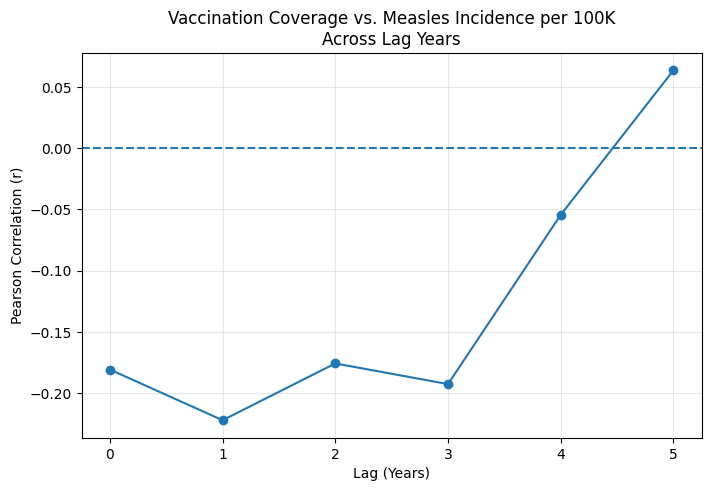

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    normalized_lag_results["lag_years"],
    normalized_lag_results["pearson_r"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Lag (Years)")
plt.ylabel("Pearson Correlation (r)")
plt.title(
    "Vaccination Coverage vs. Measles Incidence per 100K\nAcross Lag Years"
)

plt.xticks(normalized_lag_results["lag_years"])
plt.grid(alpha=0.3)

plt.show()

**Figure interpretation:** The strongest negative association between
vaccination coverage and population-normalized measles incidence was observed
at the 1-year lag (r = -0.222). Negative associations persisted through the
2- and 3-year lags, while the estimated correlations weakened at longer lags.

Interpretation of the longer lag periods should be cautious because the
number of matched state-year observations decreased substantially as the lag
increased (n = 314 at lag 0 versus n = 49 at lag 5).

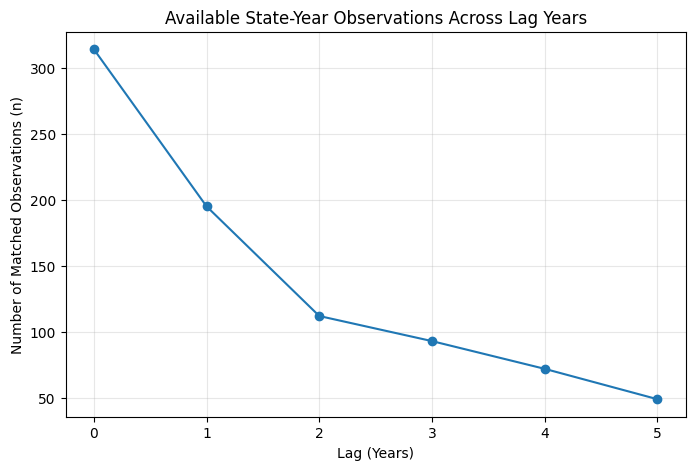

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    normalized_lag_results["lag_years"],
    normalized_lag_results["n"],
    marker="o"
)

plt.xlabel("Lag (Years)")
plt.ylabel("Number of Matched Observations (n)")
plt.title("Available State-Year Observations Across Lag Years")
plt.xticks(normalized_lag_results["lag_years"])
plt.grid(alpha=0.3)

plt.show()

**Figure interpretation:** The number of matched state-year observations
decreased substantially as the lag period increased, from 314 observations
at lag 0 to 49 observations at lag 5.

This reduction reflects limitations in overlapping vaccination coverage,
disease incidence, and population data across calendar years. The smaller
sample sizes at longer lags reduce statistical precision and limit direct
comparison of correlation estimates across lag periods.